# Blockies Dataset

This notebook download the blockies dataset and the corresponding trained model.  This is then used to evaluate the model on all datasets.  

Additionally, we provide a review of the various Blocky traits, to review the distributions between ill and healthy Blockies.

In [ ]:
import pathlib
import os
import sys
from pathlib import Path
import tarfile
import random

import string
import zipfile

import numpy as np

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms as T

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import torchvision


torch.backends.cudnn.benchmark = True

In [ ]:
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'mobilenet'

ds = 'sick_ones_bendbias_v3_2class_normal'
eval_ds = 'sick_ones_bendbias_v3_2class_variation'

random_state = 42

# Setup and Load Datasets

In [ ]:
# data downloading and dataset utilities
def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      if file_path.endswith(".tar.gz"):
        print("Extracting tar.gz file...")
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=cache_dir)
      elif file_path.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
      else:
        raise ValueError("Unsupported file format. Only .tar.gz and .zip files are supported.")

      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)

    return Path(file_path)

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['ill'])

        if self.transform:
            image = self.transform(image)

        return image, label

## Load Dataset and Dataloaders


In [ ]:
import ast
def convert_string_list_to_list(df, column_name):
    df[column_name] = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

In [ ]:
# download data direcly from sciebo

data_zip = 'https://uni-bielefeld.sciebo.de/s/MlRrDyzD0GKOK67/download'
zip_name = 'study_samples'

data_dir = download_file(url=data_zip,
                          file_name=f"{zip_name}.zip",
                          cache_dir='/content/data', # change this if not using Colab
                          extract=True,
                          force_download=True,
                          archive_folder=zip_name)
data_dir

100%|██████████| 7.81M/7.81M [00:01<00:00, 6.41MB/s]


File downloaded to: /content/data/study_samples.zip
Extracting zip file...
File extracted to: /content/data


PosixPath('/content/data/study_samples')

In [ ]:
# load and preprocess dataframes
main_dir = data_dir / 'main_data/xai_samples'
tutorial_dir = data_dir / 'tutorial_data/xai_samples'

study_df = pd.read_csv(main_dir / 'xai_samples_df.csv')
study_df = convert_string_list_to_list(study_df, 'ill_chars')
study_df['ill_label'] = study_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
study_df['pred_label'] = study_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

tutorial_df = pd.read_csv(tutorial_dir / 'xai_samples_df.csv')
tutorial_df = convert_string_list_to_list(tutorial_df, 'ill_chars')
tutorial_df['ill_label'] = tutorial_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
tutorial_df['pred_label'] = tutorial_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})


In [ ]:
# blockies v2 - 2 class dataset
mean = [0.8258, 0.8043, 0.8164]
std = [0.0768, 0.0835, 0.0904]


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])


study_dataset = ImageDataset(study_df, main_dir, transform=transform)
study_dataloader = DataLoader(study_dataset, batch_size=1, shuffle=False,
                              num_workers=6, pin_memory=True)

tutorial_dataset = ImageDataset(tutorial_df, tutorial_dir, transform=transform)
tutorial_dataloader = DataLoader(tutorial_dataset, batch_size=1, shuffle=False,
                                 num_workers=6, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
ds_dir = data_dir / ds
eval_ds_dir = data_dir / eval_ds
ds_dir, eval_ds_dir

(PosixPath('/content/data/study_samples/sick_ones_bendbias_v3_2class_normal'),
 PosixPath('/content/data/study_samples/sick_ones_bendbias_v3_2class_variation'))

# Model Loading and Evaluation





In [ ]:
def load_mobilenetv2(num_classes, pretrained=True, checkpoint_path=None):
  """Loads a MobileNetV2 model, optionally loading from a checkpoint.

  Args:
    num_classes: The number of output classes.
    pretrained: Whether to load the pre-trained weights.
    checkpoint_path: Path to a checkpoint file to load.

  Returns:
    A MobileNetV2 model.
  """
  model = models.mobilenet_v2(weights=None if not pretrained else 'DEFAULT')
  model.classifier[1] = nn.Linear(model.last_channel, num_classes)

  if checkpoint_path:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            model.load_state_dict(checkpoint["state_dict"], strict=False)
    else:
            model.load_state_dict(checkpoint, strict=False)
    print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [ ]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    preds = []
    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    print(f"Evaluation Loss: {avg_loss:.4f}, Evaluation Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy, np.array(preds)

In [ ]:
checkpoint_path = download_file(url='https://osf.io/download/5crqh/?view_only=adcc520b88cc4ea3b8236c5178ba3ab5',
                                file_name='best_model.pth',
                                cache_dir='checkpoint/mobilenetv2_checkpoint', # change this if not using Colab
                                extract=False,
                                force_download=False)
checkpoint_path

100%|██████████| 8.73M/8.73M [00:01<00:00, 7.39MB/s]

File downloaded to: checkpoint/mobilenetv2_checkpoint/best_model.pth


PosixPath('checkpoint/mobilenetv2_checkpoint/best_model.pth')

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Evaluate Model

In [ ]:
# load best model and evaluate
model = load_mobilenetv2(num_classes=len(CLASSES),
                         pretrained=False,
                         checkpoint_path=checkpoint_path)
model.to(device)

# create xai_dataloader
xai_dataset = ImageDataset(study_df, main_dir, transform=transform) # Assuming xai_df is related to study_df
xai_dataloader = DataLoader(xai_dataset, batch_size=1, shuffle=False,
                                 num_workers=6, pin_memory=True)

_, _, study_preds = evaluate_model(model, study_dataloader, criterion, device)
_, _, tutorial_preds = evaluate_model(model, tutorial_dataloader, criterion, device)
_, _, xai_preds = evaluate_model(model, xai_dataloader, criterion, device)

Loaded checkpoint from: checkpoint/mobilenetv2_checkpoint/best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Evaluation Loss: 0.7465, Evaluation Accuracy: 0.6250
Evaluation Loss: 1.5004, Evaluation Accuracy: 0.6000
Evaluation Loss: 0.7465, Evaluation Accuracy: 0.6250


In [ ]:
study_df['pred'] = study_preds
tutorial_df['pred'] = tutorial_preds
xai_df = study_df.copy()
xai_df['pred'] = xai_preds

## View the XAI Dataset

In [ ]:
def display_images(df, n_rows, n_cols, img_dir, title, random_state=0):
  """ Function to display images in a grid randomly selected from a dataframe of images.

  Args:
    df (pd.DataFrame): dataframe of images
    n_rows (int): number of rows in the grid
    n_cols (int): number of columns in the grid
    title (str): title of the plot
    random_state (int): random state for reproducibility
  """

  if n_rows == 0 and n_cols == 0:
    print(f'Not data to display for Figure - {title}')
    return

  if n_rows * n_cols < len(df):
    df = df.sample(n_rows * n_cols, random_state=random_state)

  figsize = (n_cols * 2, n_rows*2.5)
  print(figsize)

  test_images = np.array([Image.open(p).convert('RGB') for p in img_dir / df['filename']]) * 1. / 255
  fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
  axes = np.array(axes)
  for i, (ax, idx) in enumerate(zip(axes.flat, df.index)):
    ax.imshow(test_images[i])
    ax.set_title(f'True={df.loc[idx]["ill"]} - Pred={df.loc[idx]["pred"]}')
    ax.axis('off')

  fig.suptitle(title)
  fig.tight_layout()

(16, 12.5)


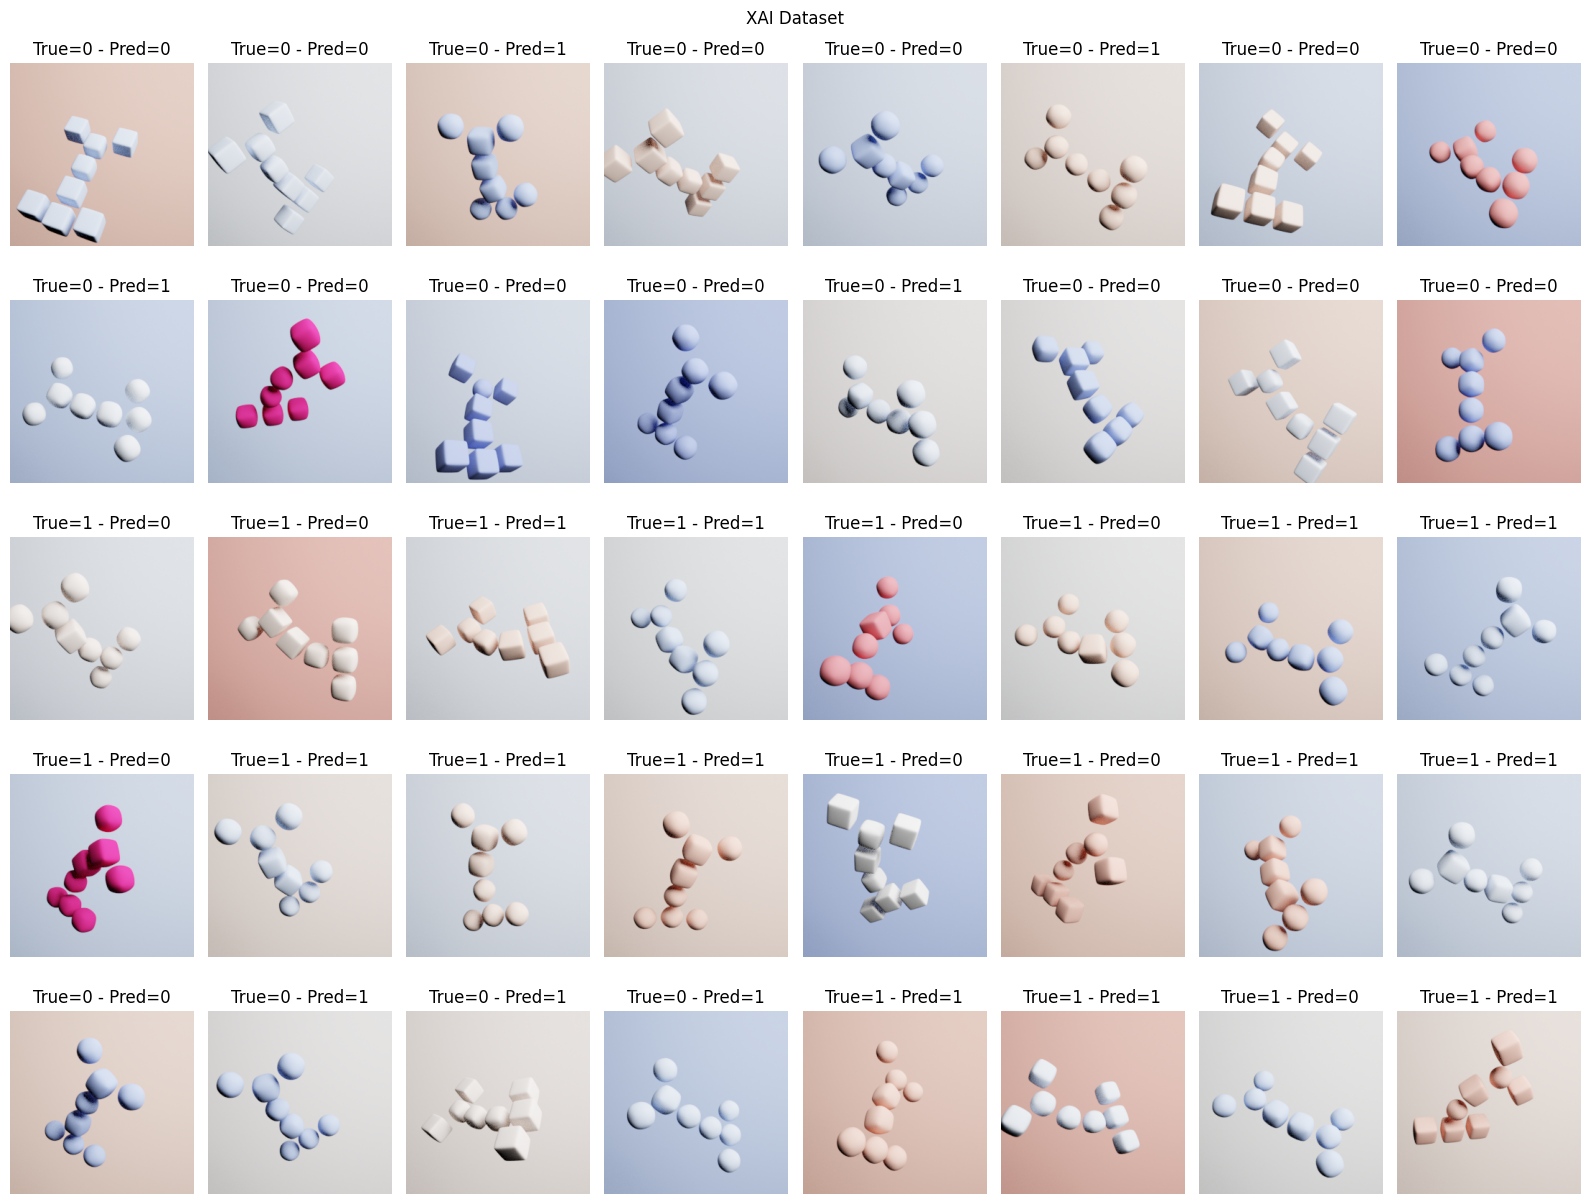

In [ ]:
display_images(xai_df, 5, 8, main_dir, f'XAI Dataset', random_state=0)

## Generate Examples

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from PIL import Image

def compute_feature_distances(target_features, dataset_features):
    """
    Compute distances between target features and all dataset examples.
    """
    distances = euclidean_distances(target_features.reshape(1, -1), dataset_features)
    return distances.flatten()

def get_closest_examples(target_features, dataset_df, feature_columns, N=5):
    """
    Find the closest N examples to the target features based on specified columns.
    """
    dataset_features = dataset_df[feature_columns].values
    # Remove the erroneous line: dataset_df = big_df[ big_df['foo'] > 0 ]

    # Compute distances using the provided dataset_df and feature columns
    distances = compute_feature_distances(target_features, dataset_features)

    # Stick them back on
    # Ensure we're working on a copy to avoid SettingWithCopyWarning later if modifying the original filtered df
    dataset_df_copy = dataset_df.copy()
    dataset_df_copy['distance'] = distances
    closest_examples = dataset_df_copy.nsmallest(N, 'distance')
    return closest_examples

def visualize_examples_with_predictions(target_image_path, target_pred, target_true, closest_examples, data_dir, class_names):
    """
    Visualize the target image, the closest examples, and their predicted classes.
    """
    # Load the target image
    target_image = Image.open(target_image_path).convert('RGB')

    # Plot target image
    plt.figure(figsize=(15, 5))
    plt.subplot(1, len(closest_examples) + 1, 1)
    plt.imshow(target_image)
    plt.title(f"Target Image\nPred: {class_names[target_pred]}\nActual: {class_names[target_true]}")
    plt.axis("off")

    # Predict and plot closest examples
    for idx, (_, row) in enumerate(closest_examples.iterrows()):
        example_image_path = data_dir / row['filename']
        example_image = Image.open(example_image_path).convert('RGB')
        pred = row['pred']
        true_label = int(row['ill'])
        predicted_class = class_names[pred]
        true_class = class_names[true_label]

        # Plot the image with prediction and distance
        plt.subplot(1, len(closest_examples) + 1, idx + 2)
        plt.imshow(example_image)
        plt.title(f"Dist: {row['distance']:.2f}\nPred: {predicted_class}\nTrue: {true_class}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# CSV Generation

import string
import random
import ast
import numpy as np
import pandas as pd
import csv

# Class labels
CLASSES = ['Healthy', 'OCDegen']

def generate_patient_id(length=10):
    return ''.join(
        random.choices(string.ascii_uppercase + string.digits, k=length)
    )

def get_caption(example_filename):
    """
    Returns a two-line caption so that CSV viewers
    will show a true line break in the cell.
    """
    row = xai_df.loc[xai_df['filename'] == example_filename]
    if row.empty:
        return "Unknown"
    true_diag      = CLASSES[int(row['ill'].values[0])]
    suggested_diag = CLASSES[int(row['pred'].values[0])]
    return f"True Diagnosis: {true_diag}\r\nSuggested Diagnosis: {suggested_diag}"

def get_xray_trait(xray_filename):
    matches = xai_df.loc[
        xai_df['filename'] == xray_filename,
        'ill_chars'
    ].values
    if len(matches) == 0:
        return "Unknown"
    ill_raw = matches[0]
    try:
        traits = ast.literal_eval(ill_raw) if isinstance(ill_raw, str) else ill_raw
    except:
        traits = []

    mapped = []
    for trait in traits:
        t = trait.strip()
        if "mutation_color" in t.lower():
            continue
        if t in ["high_bend", "med_bend"] and "Strong Spine Bend" not in mapped:
            mapped.append("Strong Spine Bend")
        elif t in ["high_sphere_diff", "med_sphere_diff"] and "Strong Bone Variation" not in mapped:
            mapped.append("Strong Bone Variation")
        elif t == "mutation_mainbones" and "Main Bones Mutation" not in mapped:
            mapped.append("Main Bones Mutation")
        elif t == "stretchy" and "Tucked Head" not in mapped:
            mapped.append("Tucked Head")
        else:
            mapped.append(t)
    return ", ".join(mapped) if mapped else "No Trait"

# Feature columns for nearest neighbors
feature_columns = [
    'main_spherical', 'sec_spherical', 'num_sec_bones', 'bending',
    'obj_rotation_roll', 'arm_position', 'obj_color', 'bg_color'
]

# Final schema
final_columns = [
    "INDEX", "PATIENT_ID", "X_RAY_IMAGE", "X_RAY_TRAIT",
    "TRUE_DIAG", "SUGGESTED_DIAG",
    "Example1", "Example1_Caption",
    "Example2", "Example2_Caption",
    "Example3", "Example3_Caption",
    "X_RAY_LOCATION"
]

# Start with an empty DataFrame
df = pd.DataFrame(columns=final_columns)

# Build one row per X-ray
for _, row in xai_df.iterrows():
    target_features = row[feature_columns].values
    target_true     = int(row['ill'])
    target_pred     = int(row['pred'])
    id_to_drop      = row['id']

    filtered = xai_df[xai_df['id'] != id_to_drop]
    closest_examples = get_closest_examples(
        target_features, filtered, feature_columns, N=3
    )

    new_row = {
        "PATIENT_ID": generate_patient_id(),
        "X_RAY_IMAGE": row['filename'],
        "TRUE_DIAG": CLASSES[target_true],
        "SUGGESTED_DIAG": CLASSES[target_pred],
        "Example1": closest_examples['filename'].iloc[0],
        "Example2": closest_examples['filename'].iloc[1],
        "Example3": closest_examples['filename'].iloc[2],
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

# Fill in captions & traits
df['Example1_Caption'] = df['Example1'].apply(get_caption)
df['Example2_Caption'] = df['Example2'].apply(get_caption)
df['Example3_Caption'] = df['Example3'].apply(get_caption)
df['X_RAY_TRAIT']      = df['X_RAY_IMAGE'].apply(get_xray_trait)

# Random locations
locations = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]
df["X_RAY_LOCATION"] = random.choices(locations, k=len(df))

# Refresh INDEX
if "INDEX" in df.columns:
    df = df.drop(columns=["INDEX"])
df["INDEX"] = random.sample(range(1, 100 + len(df)), len(df))

# Reorder & save with quoting so newlines persist
df = df[final_columns]
df.to_csv(
    "input_example.csv",
    index=False,
    quoting=csv.QUOTE_ALL
)
print("Saved input_example.csv with multiline captions")

Saved input_example.csv with multiline captions


In [ ]:
df

,INDEX,PATIENT_ID,X_RAY_IMAGE,X_RAY_TRAIT,TRUE_DIAG,SUGGESTED_DIAG,Example1,Example1_Caption,Example2,Example2_Caption,Example3,Example3_Caption,X_RAY_LOCATION
0,92,CZOBEBVFR3,cec708b5-2af1-454b-a0c8-8c8047565127.png,No Trait,Healthy,Healthy,886df72b-9dc5-4cf7-ab58-86d0cfa911c1.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,41bab120-6bd7-45cb-a964-ed69d8b49727.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,33f21483-6240-4fd5-95bc-36be485b3259.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,CHI
1,135,M97RKRIWCT,33f21483-6240-4fd5-95bc-36be485b3259.png,Tucked Head,Healthy,Healthy,886df72b-9dc5-4cf7-ab58-86d0cfa911c1.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,d2fa9641-b965-411e-8256-95e8533a017e.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,cec708b5-2af1-454b-a0c8-8c8047565127.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,DEN
2,10,ITEM0Y2IVH,990bf4f1-d7e2-4255-88f8-1b5b41138402.png,No Trait,Healthy,OCDegen,b3458f5b-9f17-4186-90ca-57e8bf1bc739.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,685844cf-2fe6-4a59-983d-7fbe811019fc.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,9213cdfb-29b5-43c7-9703-231baf712716.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,DEN
3,59,Z1MALDNZTC,41bab120-6bd7-45cb-a964-ed69d8b49727.png,No Trait,Healthy,Healthy,2a32295f-1fd8-4307-9ce8-25610d1138b6.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,886df72b-9dc5-4cf7-ab58-86d0cfa911c1.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,cec708b5-2af1-454b-a0c8-8c8047565127.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,ATL
4,66,GP5H9NNPTD,e0230a28-426a-4a85-b461-b2fc9633cf47.png,Strong Bone Variation,Healthy,Healthy,50a09ffc-d0f5-44aa-adea-bb7b9623c9cc.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,a8b35c43-d857-47ca-8ebf-c33fcab65f95.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,685844cf-2fe6-4a59-983d-7fbe811019fc.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,MIA
5,137,CWELQI22FP,63daf4a2-152f-4432-b55d-2da75976fbf3.png,No Trait,Healthy,OCDegen,6f873d5d-a630-4ee4-8fe0-715a005e7623.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,c8f0e96e-e697-47f8-b67a-2e1b54d5be19.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,4f13d1ec-1b42-4900-beba-981058d1220f.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,CHI
6,23,KSMAAEFO83,d59bf4e5-b1e8-48fb-8b8a-c73bc831a150.png,Tucked Head,Healthy,Healthy,d60d1a46-fab6-4b05-9472-f53ef0d3272e.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,58567d1a-14c6-4d82-aafa-16c362d827e1.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,48fedf95-d9bb-45c5-9095-5750f736f29b.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,SEA
7,83,STDA4RO2FW,48fedf95-d9bb-45c5-9095-5750f736f29b.png,Strong Spine Bend,Healthy,Healthy,5c9d10ec-47a5-471a-bb06-31117ebf51e8.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,2723232d-db8a-41a4-8c02-498dcb88baa6.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,567f3d6f-79f6-4c47-8664-8bf526dd2a3b.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,BOS
8,32,SCLCZXBU4Y,9213cdfb-29b5-43c7-9703-231baf712716.png,Main Bones Mutation,Healthy,OCDegen,09feae00-4158-40fc-8d65-173b13a9cc76.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,b3458f5b-9f17-4186-90ca-57e8bf1bc739.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,990bf4f1-d7e2-4255-88f8-1b5b41138402.png,True Diagnosis: Healthy\r\nSuggested Diagnosis...,MIA
9,34,ILDTXSLEXG,e91b807f-4d76-4422-a61a-d2731ee93b49.png,Strong Spine Bend,Healthy,Healthy,bb3c7b79-aecb-4e54-a21b-d7f4533ba879.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,d2fa9641-b965-411e-8256-95e8533a017e.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,3e70c3ac-0617-4b74-bee4-ac2389f6a97c.png,True Diagnosis: OCDegen\r\nSuggested Diagnosis...,ATL


In [ ]:
#Zipfile

from pathlib import Path

image_dir = main_dir # Changed to main_dir as per previous fix
zip_filename = "study_images_example.zip"

filecols = ['X_RAY_IMAGE', 'Example1', 'Example2', 'Example3']
unique_files = pd.unique(df[filecols].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in unique_files:
        img_path = image_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(unique_files)} images to {zip_filename}")

Saved 40 images to study_images_example.zip
